✅ Données chargées avec succès: 55 images analysées
📊 Colonnes disponibles: ['name', 'mIoU', 'IoU_rust', 'IoU_PM', 'IoU_leaf', 'IoU_background', 'surfPred_rust', 'surfPred_PM', 'surfPred_leaf', 'surfPred_background', 'surfGT_rust', 'surfGT_PM', 'surfGT_leaf', 'surfGT_background', 'image_type', 'total_surface_pred', 'total_surface_gt', 'error_rust', 'error_PM', 'error_leaf', 'error_background']
📈 STATISTIQUES DES PERFORMANCES
         mIoU  IoU_rust  IoU_PM  IoU_leaf  IoU_background
count  55.000    55.000  55.000    55.000          55.000
mean    0.605     0.307   0.191     0.954           0.967
std     0.073     0.252   0.204     0.030           0.018
min     0.486     0.000   0.000     0.855           0.900
25%     0.553     0.014   0.003     0.946           0.959
50%     0.598     0.320   0.072     0.958           0.970
75%     0.652     0.554   0.360     0.977           0.979
max     0.791     0.741   0.641     0.990           0.989

🏷️  PERFORMANCE PAR TYPE D'IMAGE
             me

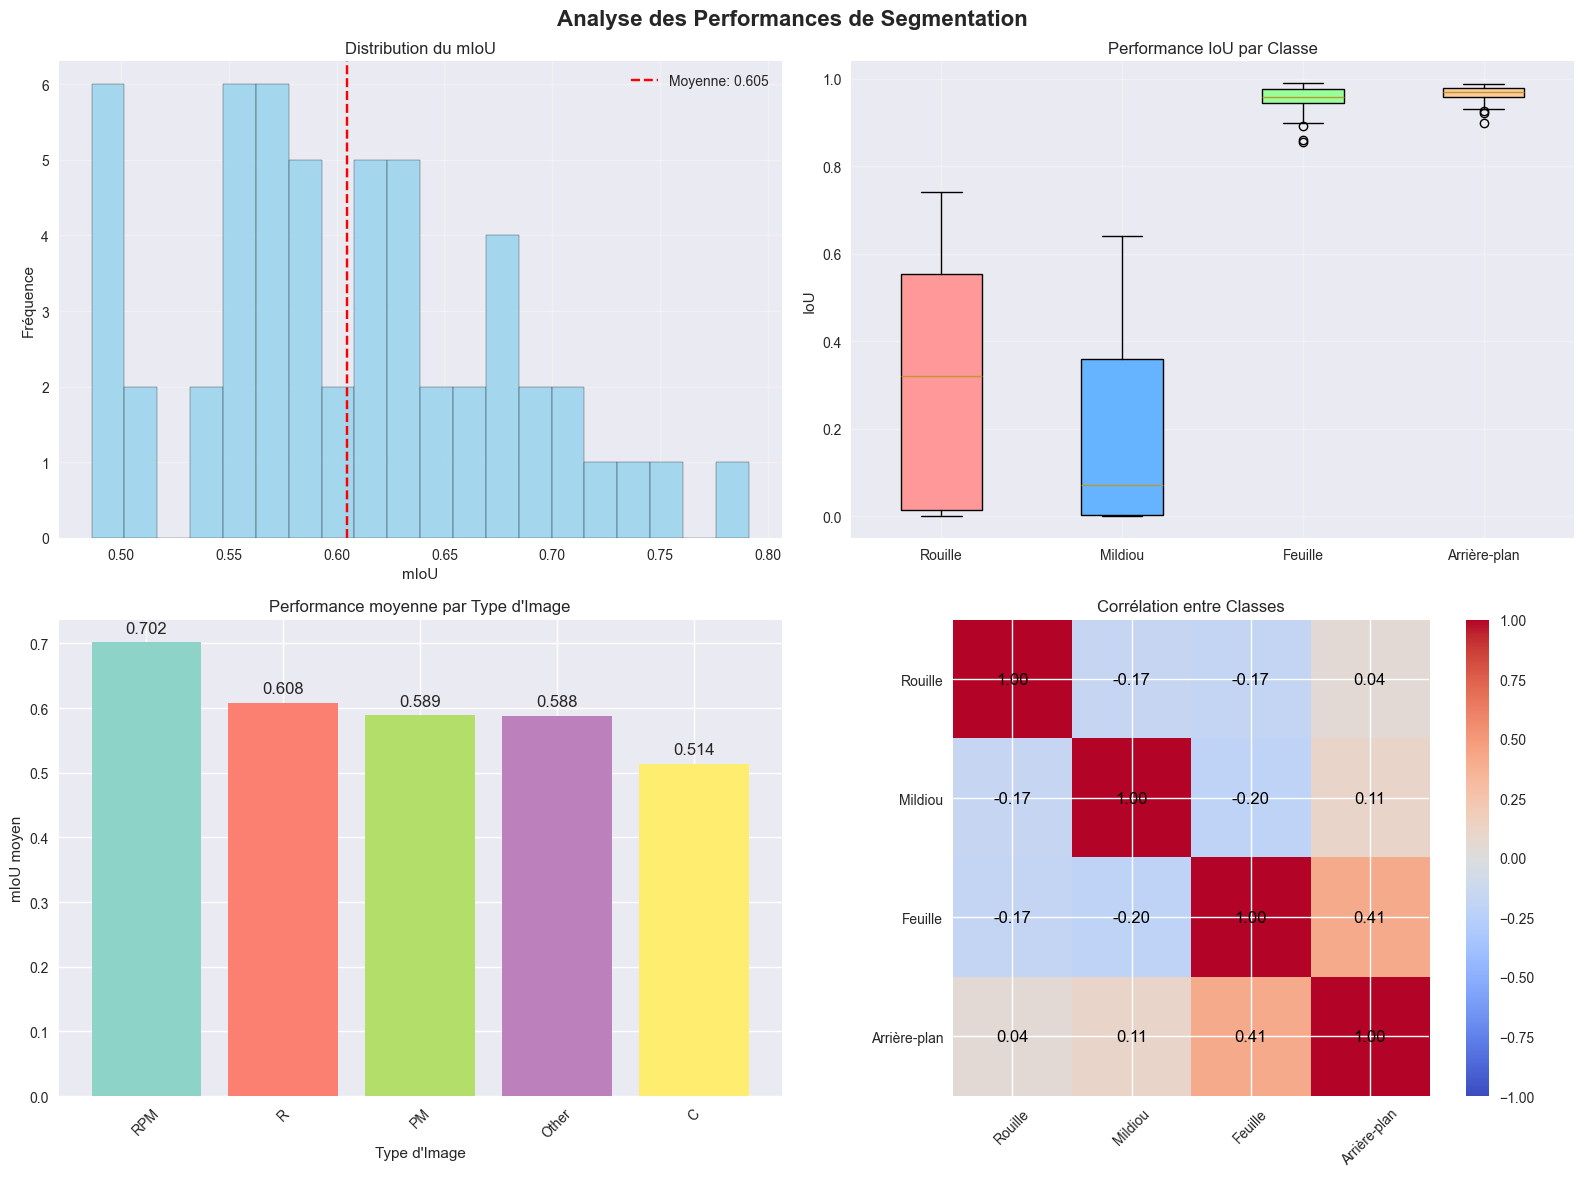

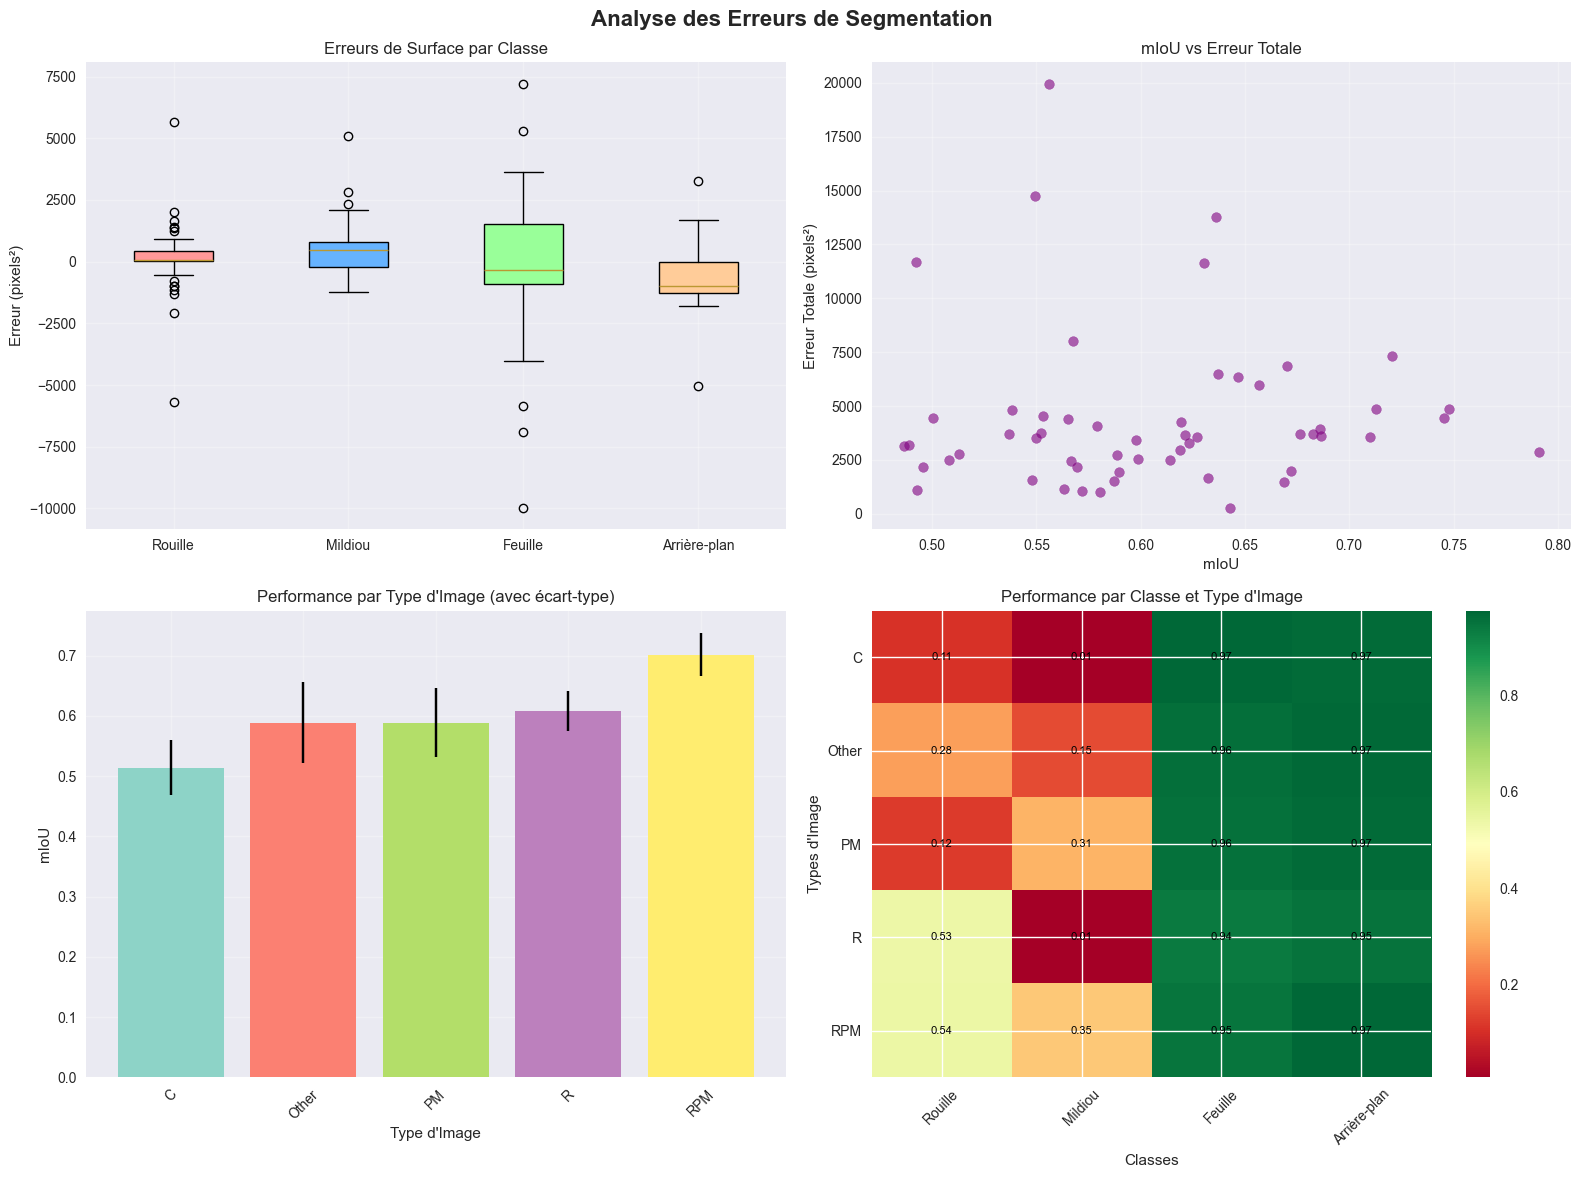

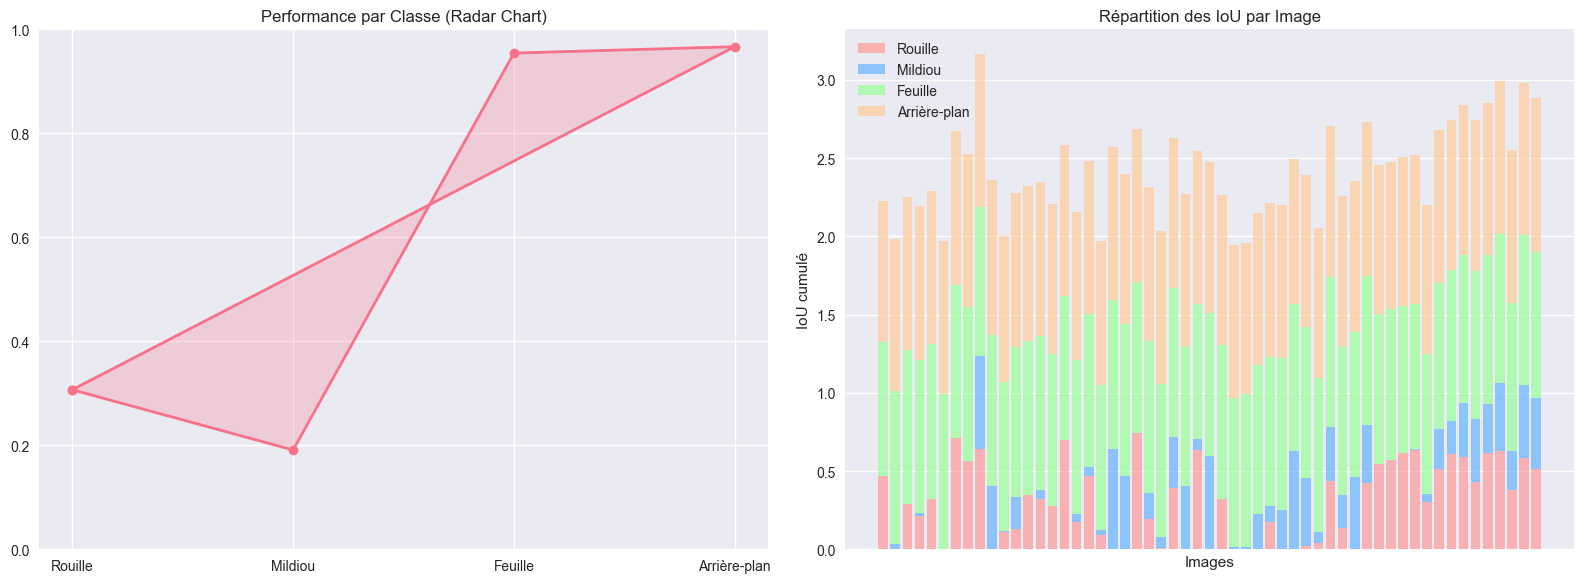


📝 TABLEAU SYNTHÉTIQUE (Rouille / Mildiou poudreux)
                     rust  powdery mildew
precision           0.405           0.260
recall              0.448           0.381
F1-score            0.425           0.309
IoU                 0.307           0.191
surface Error (%)  10.456          46.379

📊 RÉSUMÉ DES PERFORMANCES
mIoU global: 0.605 ± 0.073
Meilleure performance: 0.791 (251_leaf4)
Plus faible performance: 0.486 (C_8)

🏆 PERFORMANCE PAR CLASSE:
  Rouille: 0.307 ± 0.252
  Mildiou: 0.191 ± 0.204
  Feuille: 0.954 ± 0.030
  Arrière-plan: 0.967 ± 0.018

💡 RECOMMANDATIONS:
  • Améliorer la détection du mildiou (performance la plus faible)
  • Augmenter le dataset avec plus d'exemples de maladies
  • Optimiser le modèle pour les classes minoritaires
  • Considérer des techniques de data augmentation
  • Analyser les cas d'échec pour améliorer la robustesse

💾 Export des résultats...
✅ Résultats exportés dans le répertoire 'analysis_results'
📁 Fichiers créés:
   - summary_statist

In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Analyse des Performances de Segmentation

Ce script analyse les performances d'un modèle de segmentation de maladies foliaires
à partir d'un fichier CSV contenant les métriques d'évaluation.
"""

import pandas as pd

def load_and_prepare_data(file_path):
    """
    Charge et prépare les données d'évaluation
    
    Args:
        file_path (str): Chemin vers le fichier CSV
    
    Returns:
        pd.DataFrame: Données préparées
    """
    # Chargement des données
    df = pd.read_csv(file_path)
    
    # Extraction du type d'image depuis le nom
    df['image_type'] = df['name'].str.extract(r'([A-Z]+)_?\d*')[0]
    df['image_type'] = df['image_type'].fillna('Other')
    
    # Calcul des métriques supplémentaires
    df['total_surface_pred'] = df[['surfPred_rust', 'surfPred_PM', 'surfPred_leaf', 'surfPred_background']].sum(axis=1)
    df['total_surface_gt'] = df[['surfGT_rust', 'surfGT_PM', 'surfGT_leaf', 'surfGT_background']].sum(axis=1)
    
    # Calcul des erreurs de surface
    for class_name in ['rust', 'PM', 'leaf', 'background']:
        df[f'error_{class_name}'] = df[f'surfPred_{class_name}'] - df[f'surfGT_{class_name}']
    
    return df
    # Rust
    surf_pred_rust = df['surfPred_rust'].sum()
    surf_gt_rust = df['surfGT_rust'].sum()
    IoU_rust = df['IoU_rust'].mean()
    union_rust = surf_pred_rust + surf_gt_rust - IoU_rust * (surf_pred_rust + surf_gt_rust)
    intersection_rust = IoU_rust * (surf_pred_rust + surf_gt_rust - IoU_rust * (surf_pred_rust + surf_gt_rust))
    TP_rust = intersection_rust
    FP_rust = surf_pred_rust - intersection_rust
    FN_rust = surf_gt_rust - intersection_rust
    precision_rust = safe_div(TP_rust, TP_rust + FP_rust)
    recall_rust = safe_div(TP_rust, TP_rust + FN_rust)
    F1_rust = safe_div(2 * precision_rust * recall_rust, precision_rust + recall_rust)
    surface_error_rust = safe_div(surf_pred_rust - surf_gt_rust, surf_gt_rust) * 100

    # PM (powdery mildew)
    surf_pred_PM = df['surfPred_PM'].sum()
    surf_gt_PM = df['surfGT_PM'].sum()
    IoU_PM = df['IoU_PM'].mean()
    union_PM = surf_pred_PM + surf_gt_PM - IoU_PM * (surf_pred_PM + surf_gt_PM)
    intersection_PM = IoU_PM * (surf_pred_PM + surf_gt_PM - IoU_PM * (surf_pred_PM + surf_gt_PM))
    TP_PM = intersection_PM
    FP_PM = surf_pred_PM - intersection_PM
    FN_PM = surf_gt_PM - intersection_PM
    precision_PM = safe_div(TP_PM, TP_PM + FP_PM)
    recall_PM = safe_div(TP_PM, TP_PM + FN_PM)
    F1_PM = safe_div(2 * precision_PM * recall_PM, precision_PM + recall_PM)
    surface_error_PM = safe_div(surf_pred_PM - surf_gt_PM, surf_gt_PM) * 100

    # Tableau pandas
    summary_table = pd.DataFrame({
        "rust": [precision_rust, recall_rust, F1_rust, IoU_rust, surface_error_rust],
        "powdery mildew": [precision_PM, recall_PM, F1_PM, IoU_PM, surface_error_PM]
    }, index=["precision", "recall", "F1-score", "IoU", "surface Error (%)"])

    print("\n📝 TABLEAU SYNTHÉTIQUE (Rouille / Mildiou poudreux)")
    print("=" * 50)
    print(summary_table.round(3))

    # Résumé textuel
    print("\n📊 RÉSUMÉ DES PERFORMANCES")
    print("=" * 50)
    print(f"mIoU global: {df['mIoU'].mean():.3f} ± {df['mIoU'].std():.3f}")
    print(f"Meilleure performance: {df['mIoU'].max():.3f} ({df.loc[df['mIoU'].idxmax(), 'name']})")
    print(f"Plus faible performance: {df['mIoU'].min():.3f} ({df.loc[df['mIoU'].idxmin(), 'name']})")
    
    print("\n🏆 PERFORMANCE PAR CLASSE:")
    for col, name in zip(class_metrics, class_names):
        mean_val = df[col].mean()
        std_val = df[col].std()
        print(f"  {name}: {mean_val:.3f} ± {std_val:.3f}")
    
    print("\n💡 RECOMMANDATIONS:")
    print("  • Améliorer la détection du mildiou (performance la plus faible)")
    print("  • Augmenter le dataset avec plus d'exemples de maladies")
    print("  • Optimiser le modèle pour les classes minoritaires")
    print("  • Considérer des techniques de data augmentation")
    print("  • Analyser les cas d'échec pour améliorer la robustesse")

def export_analysis_results(df, output_dir='analysis_results'):
    """
    Exporte les résultats d'analyse dans des fichiers
    
    Args:
        df (pd.DataFrame): Données d'analyse
        output_dir (str): Répertoire de sortie
    """
    # Créer le répertoire de sortie
    Path(output_dir).mkdir(exist_ok=True)
    
    # 1. Résumé statistique
    summary_stats = df[['mIoU', 'IoU_rust', 'IoU_PM', 'IoU_leaf', 'IoU_background']].describe()
    summary_stats.to_csv(f'{output_dir}/summary_statistics.csv')
    
    # 2. Performance par type d'image
    type_performance = df.groupby('image_type').agg({
        'mIoU': ['mean', 'std', 'count'],
        'IoU_rust': 'mean',
        'IoU_PM': 'mean',
        'IoU_leaf': 'mean',
        'IoU_background': 'mean'
    }).round(3)
    type_performance.to_csv(f'{output_dir}/performance_by_type.csv')
    
    # 3. Top et bottom performers
    top_performers = df.nlargest(10, 'mIoU')[['name', 'mIoU', 'image_type']]
    bottom_performers = df.nsmallest(10, 'mIoU')[['name', 'mIoU', 'image_type']]
    
    top_performers.to_csv(f'{output_dir}/top_performers.csv', index=False)
    bottom_performers.to_csv(f'{output_dir}/bottom_performers.csv', index=False)
    
    # 4. Rapport textuel
    with open(f'{output_dir}/analysis_report.txt', 'w', encoding='utf-8') as f:
        f.write("RAPPORT D'ANALYSE DES PERFORMANCES\n")
        f.write("=" * 50 + "\n\n")
        
        f.write(f"Nombre total d'images analysées: {len(df)}\n")
        f.write(f"mIoU moyen: {df['mIoU'].mean():.3f}\n")
        f.write(f"Écart-type mIoU: {df['mIoU'].std():.3f}\n\n")
        
        f.write("PERFORMANCE PAR CLASSE:\n")
        for col, name in zip(['IoU_rust', 'IoU_PM', 'IoU_leaf', 'IoU_background'], 
                             ['Rouille', 'Mildiou', 'Feuille', 'Arrière-plan']):
            f.write(f"  {name}: {df[col].mean():.3f} ± {df[col].std():.3f}\n")
        
        f.write("\nPERFORMANCE PAR TYPE D'IMAGE:\n")
        type_stats = df.groupby('image_type')['mIoU'].agg(['mean', 'std', 'count'])
        for img_type, stats in type_stats.iterrows():
            f.write(f"  {img_type}: {stats['mean']:.3f} ± {stats['std']:.3f} (n={stats['count']})\n")
    
    print(f"✅ Résultats exportés dans le répertoire '{output_dir}'")
    print(f"📁 Fichiers créés:")
    print(f"   - summary_statistics.csv")
    print(f"   - performance_by_type.csv")
    print(f"   - top_performers.csv")
    print(f"   - bottom_performers.csv")
    print(f"   - analysis_report.txt")

def analyze_new_file(file_path):
    """
    Fonction pour analyser un nouveau fichier de résultats
    
    Args:
        file_path (str): Chemin vers le fichier CSV
    """
    try:
        # Charger les nouvelles données
        new_df = load_and_prepare_data(file_path)
        
        print(f"✅ Nouveau fichier analysé: {file_path}")
        print(f"📊 {len(new_df)} images analysées")
        print(f"📈 mIoU moyen: {new_df['mIoU'].mean():.3f}")
        
        return new_df
        
    except Exception as e:
        print(f"❌ Erreur lors de l'analyse du fichier: {e}")
        return None

def main():
    """Fonction principale"""
    # Chargement des données
    try:
        df = load_and_prepare_data('results_normal.csv')
        print(f"✅ Données chargées avec succès: {len(df)} images analysées")
        print(f"📊 Colonnes disponibles: {list(df.columns)}")
    except FileNotFoundError:
        print("❌ Fichier 'results_normal.csv' non trouvé. Veuillez spécifier le bon chemin.")
        return
    
    # Affichage des statistiques
    print_summary_statistics(df)
    
    # Création des visualisations
    print("\n📈 Création des visualisations...")
    create_performance_visualizations(df)
    create_error_analysis(df)
    create_comparative_analysis(df)
    
    # Export des résultats
    print("\n💾 Export des résultats...")
    export_analysis_results(df)
    
    print("\n🎉 Analyse terminée!")

if __name__ == "__main__":
    main()

In [7]:
import pandas as pd

# Supposons que df est déjà chargé dans le notebook
# On extrait les colonnes nécessaires pour la rouille (rust) et l'oïdium (powdery mildew)
# On suppose que les colonnes sont nommées comme suit :
# - precision_rust, recall_rust, f1_rust, IoU_rust, surface_error_percent_rust
# - precision_PM, recall_PM, f1_PM, IoU_PM, surface_error_percent_PM

# Si les colonnes sont nommées différemment, adaptez les noms ci-dessous

# Calcul des moyennes pour chaque métrique
metrics = {
    "precision": [
        df["precision_rust"].mean() if "precision_rust" in df.columns else float('nan'),
        df["precision_PM"].mean() if "precision_PM" in df.columns else float('nan')
    ],
    "recall": [
        df["recall_rust"].mean() if "recall_rust" in df.columns else float('nan'),
        df["recall_PM"].mean() if "recall_PM" in df.columns else float('nan')
    ],
    "F1-score": [
        df["f1_rust"].mean() if "f1_rust" in df.columns else float('nan'),
        df["f1_PM"].mean() if "f1_PM" in df.columns else float('nan')
    ],
    "IoU": [
        df["IoU_rust"].mean() if "IoU_rust" in df.columns else float('nan'),
        df["IoU_PM"].mean() if "IoU_PM" in df.columns else float('nan')
    ],
    "surface d'erreur (%)": [
        df["surface_error_percent_rust"].mean() if "surface_error_percent_rust" in df.columns else float('nan'),
        df["surface_error_percent_PM"].mean() if "surface_error_percent_PM" in df.columns else float('nan')
    ]
}

# Création du DataFrame pour affichage
table = pd.DataFrame(
    metrics,
    index=["rust", "powdery mildew"]
).T

# Affichage du tableau
print("Tableau des métriques pour rust et powdery mildew :")
display(table.style.format("{:.3f}"))



NameError: name 'df' is not defined